# 05 — Turning (Figure 5)

<img src="figures/DMD_figure5.png" width="600"/>


This notebook reproduces **Figure 5**: DMD analysis of left and right turns during obstacle avoidance flights. The turning data comprises flights by one individual, Toothless, split by turn direction.

We show that DMD captures mirrored banking modes as well as an asymmetric turning mode that distinguishes left from right manoeuvres.

<div style="display: flex; flex-direction: row; width: 100%; justify-content: space-between; margin-bottom: 10px;">
  <img src="figures/05_right_turn_mode_0.gif" style="width: 32%;"/>
  <img src="figures/05_right_turn_mode_1.gif" style="width: 32%;"/>
  <img src="figures/05_right_turn_mode_2.gif" style="width: 32%;"/>
</div>
<div style="display: flex; flex-direction: row; width: 100%; justify-content: space-between;">
  <img src="figures/05_left_turn_mode_0.gif" style="width: 32%;"/>
  <img src="figures/05_left_turn_mode_1.gif" style="width: 32%;"/>
  <img src="figures/05_left_turn_mode_2.gif" style="width: 32%;"/>
</div>

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget
%config InlineBackend.figure_format='svg'

import matplotlib.pyplot as plt
import numpy as np
from morphing_birds import (
    Animal3D,
    animate,
    animate_compare,
    animate_plotly_compare,
    plot_plotly_with_trace,
)

from birddmd import compute_rmse, plot_mode_dynamics, reconstruct, run_dmd

In [2]:
hawk3d = Animal3D("hawk", "../data/mean_hawk_shape.csv")
average_shape = hawk3d.markers
n_markers = 8
N_MODES = 6

D = 2

## 1 — Load turning data

We load left and right turn data for Toothless at 9 m. Both conditions come from a single combined full-flight file (`Full_9mObstacleToothless_BilateralNoRot.npz`), split by the Turn column and time-filtered to match the original analysis.

The preparation script (`scripts/prepare_turning.py`) splits the combined file by turn direction and applies condition-specific time filters. Expand the cell below to review the pipeline.

In [3]:
# %load scripts/prepare_turning.py


In [4]:
loaded_dataset = np.load("../data/processed/Toothless_turning_binned.npz")
conditions = {
    "Left turn": ("markers_left", "times_left"),
    "Right turn": ("markers_right", "times_right"),
}

all_results = {}

for label, (ii_markers, ii_times) in conditions.items():
    print(f"\n--- {label} ---")
    markers = loaded_dataset[ii_markers]
    times = loaded_dataset[ii_times]

    result = run_dmd(
        data=markers,
        times=times,
        n_modes=N_MODES,
        d=D,
        eig_constraints={"conjugate_pairs"},
        n_markers=n_markers,
        average_shape=average_shape,
        verbose=False,
    )

    all_results[label] = {
        "result": result,
        "markers": markers,
        "times": times,
    }

    print(f"  {markers.shape[0]} frames, {result.n_pairs} pairs")
    for idx in range(result.n_pairs):
        print(f"  Pair {idx + 1}: {result.pair_frequency(idx):.2f} Hz")


--- Left turn ---
  270 frames, 3 pairs
  Pair 1: 4.56 Hz
  Pair 2: 0.93 Hz
  Pair 3: 0.20 Hz

--- Right turn ---
  260 frames, 3 pairs
  Pair 1: 4.45 Hz
  Pair 2: 1.07 Hz
  Pair 3: 0.22 Hz


## 2 — Mode dynamics comparison

The dynamics plots below show the temporal evolution of each conjugate pair for each condition. Look for modes whose amplitude or phase differs between left and right turns — these capture the asymmetric banking component of the manoeuvre.


Left turn
Pair 1 (0,1) Frequency: 4.56 Hz | f=4.56 Hz | λ=-1.860+28.671j
Pair 2 (2,3) Frequency: 0.93 Hz | f=0.93 Hz | λ=-1.049+5.868j
Pair 3 (4,5) Frequency: 0.20 Hz | f=0.20 Hz | λ=0.385+1.286j


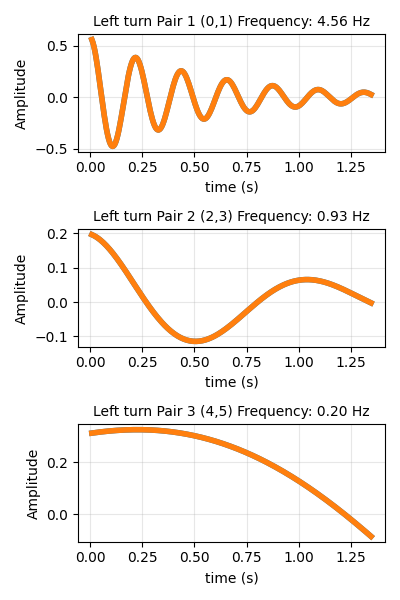


Right turn
Pair 1 (0,1) Frequency: 4.45 Hz | f=4.45 Hz | λ=-1.669+27.953j
Pair 2 (2,3) Frequency: 1.07 Hz | f=1.07 Hz | λ=-0.402+6.746j
Pair 3 (4,5) Frequency: -0.22 Hz | f=-0.22 Hz | λ=0.493-1.411j


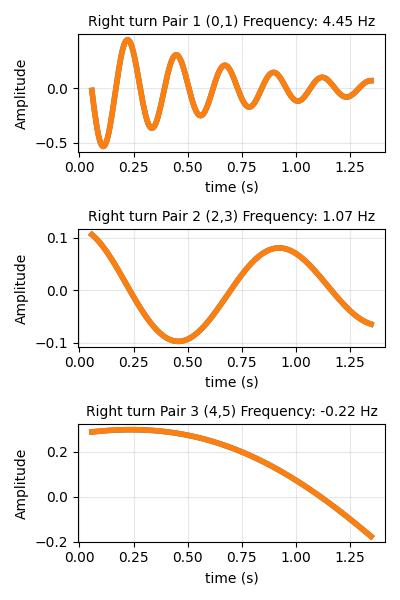

In [5]:
for label, res in all_results.items():
    print(f"\n{label}")
    fig = plot_mode_dynamics(
        res["result"].times[1:],
        res["result"],
        title_prefix=label,
        y_lim=None,
        axes_visible=True,
    )
    clean = label.lower().replace(" ", "_").replace("(", "").replace(")", "")
    fig.savefig(
        f"figures/05_dynamics_{clean}.svg",
        format="svg",
    )

## 3 — Visualise turning modes

We first compare the wingbeat mode (pair 0) for left and right turns side by side — the two reconstructions should appear as approximate mirror images, reflecting the bilateral symmetry of the banking motion.

We then decompose the right turn into individual mode contributions, following the same approach as notebook 01.

In [6]:
# Compare left and right turn first mode pair (wingbeat)
# hawk3d = Animal3D('hawk', "../data/mean_hawk_shape.csv")

left_res = all_results["Left turn"]["result"]
right_res = all_results["Right turn"]["result"]

# Reconstruct wingbeat mode for each
left_wb = reconstruct(left_res, pairs=[0])
right_wb = reconstruct(right_res, pairs=[0])

# Trim to equal length
min_len = min(left_wb.shape[0], right_wb.shape[0])
left_wb = left_wb[:min_len]
right_wb = right_wb[:min_len]

# animate_plotly_compare(
#     hawk3d,
#     keypoints_frames_list=[left_wb, right_wb],
#     colours=["blue", "red"],
# )

In [7]:
# # Save left vs right wingbeat comparison as GIF
# hawk3d = Animal3D('hawk', "../data/mean_hawk_shape.csv")
# ani = animate_compare(
#     hawk3d, [left_wb, right_wb],
#     colour=["blue", "red"], az=50, el=30,
# )
# ani.save("figures/05_left_vs_right_wingbeat.gif", writer='Pillow', fps=40, dpi=300)
# print("Saved figures/05_left_vs_right_wingbeat.gif")

<img src="figures/05_left_vs_right_wingbeat.gif" width="400"/>


In [8]:
# RMSE for each condition
for label, res in all_results.items():
    result = res["result"]
    markers_compare = res["markers"][:-1]
    rmse = compute_rmse(result.reconstruction, markers_compare)
    print(f"{label}: mean RMSE = {np.mean(rmse):.6f} m")

Left turn: mean RMSE = 0.029274 m
Right turn: mean RMSE = 0.030195 m


In [9]:
# Reconstruct each conjugate pair separately for the right turn
conjugate_pairs = right_res.conjugate_pairs
n_pairs = len(conjugate_pairs)

pair_colours = ["#DF5D99", "#57B7B0", "#EE7447", "#6B5B95", "#88B04B"][:n_pairs]

mode_keypoints = []
pair_labels = []
for pair_idx in range(n_pairs):
    kp = reconstruct(right_res, pairs=[pair_idx])
    mode_keypoints.append(kp)
    freq = right_res.pair_frequency(pair_idx)
    label = f"{freq:.2f} Hz"
    pair_labels.append(label)
    i, j = conjugate_pairs[pair_idx]
    print(f"  Pair {pair_idx + 1} ({label}): modes ({i},{j})")

  Pair 1 (4.45 Hz): modes (0,1)
  Pair 2 (1.07 Hz): modes (2,3)
  Pair 3 (0.22 Hz): modes (4,5)


In [10]:
# Save each right-turn mode pair as a GIF
# hawk3d = Animal3D('hawk', "../data/mean_hawk_shape.csv")
# for pair_idx, (kp, label, colour) in enumerate(
#     zip(mode_keypoints, pair_labels, pair_colours)
# ):
#     ani = animate(hawk3d, kp, colour=colour, az=90, el=10)
#     ani.save(
#         f"figures/05_right_turn_mode_{pair_idx}.gif",
#         writer="Pillow", fps=40, dpi=300,
#     )
#     print(f"Saved figures/05_right_turn_mode_{pair_idx}.gif ({label})")

In [11]:
# Reconstruct each conjugate pair separately for the right turn
conjugate_pairs = left_res.conjugate_pairs
n_pairs = len(conjugate_pairs)

pair_colours = ["#DF5D99", "#57B7B0", "#EE7447", "#6B5B95", "#88B04B"][:n_pairs]

mode_keypoints = []
pair_labels = []
for pair_idx in range(n_pairs):
    kp = reconstruct(left_res, pairs=[pair_idx])
    mode_keypoints.append(kp)
    freq = left_res.pair_frequency(pair_idx)
    label = f"{freq:.2f} Hz"
    pair_labels.append(label)
    i, j = conjugate_pairs[pair_idx]
    print(f"  Pair {pair_idx + 1} ({label}): modes ({i},{j})")

  Pair 1 (4.56 Hz): modes (0,1)
  Pair 2 (0.93 Hz): modes (2,3)
  Pair 3 (0.20 Hz): modes (4,5)


In [12]:
# Save each left-turn mode pair as a GIF
# hawk3d = Animal3D('hawk', "../data/mean_hawk_shape.csv")
# for pair_idx, (kp, label, colour) in enumerate(
#     zip(mode_keypoints, pair_labels, pair_colours)
# ):
#     ani = animate(hawk3d, kp, colour=colour, az=90, el=10)
#     ani.save(
#         f"figures/05_left_turn_mode_{pair_idx}.gif",
#         writer="Pillow", fps=40, dpi=300,
#     )
#     print(f"Saved figures/05_left_turn_mode_{pair_idx}.gif ({label})")

<div style="display: flex; flex-direction: row; width: 100%; justify-content: space-between; margin-bottom: 10px;">
  <img src="figures/05_right_turn_mode_0.gif" style="width: 32%;"/>
  <img src="figures/05_right_turn_mode_1.gif" style="width: 32%;"/>
  <img src="figures/05_right_turn_mode_2.gif" style="width: 32%;"/>
</div>
<div style="display: flex; flex-direction: row; width: 100%; justify-content: space-between;">
  <img src="figures/05_left_turn_mode_0.gif" style="width: 32%;"/>
  <img src="figures/05_left_turn_mode_1.gif" style="width: 32%;"/>
  <img src="figures/05_left_turn_mode_2.gif" style="width: 32%;"/>
</div>

In [13]:
# # 3D visualisation of individual modes
# for pair_idx, (kp, label, colour) in enumerate(
#     zip(mode_keypoints, pair_labels, pair_colours)
# ):
#     hawk3d = Animal3D('hawk', "../data/mean_hawk_shape.csv")
#     hawk3d.update_keypoints(kp[0])
#
#     fig = plot_plotly_with_trace(hawk3d, keypoints_frames=kp, colour=colour)
#     fig.update_layout(
#         scene=dict(
#             camera=dict(eye=dict(x=0.0, y=1, z=0.3)),
#             xaxis=dict(visible=False, range=[-0.8, 0.8]),
#             yaxis=dict(visible=False, range=[-0.8, 0.8]),
#             zaxis=dict(visible=False, range=[-0.8, 0.8]),
#         ),
#     )
#     fig.show()

In [14]:
# hawk3d = Animal3D('hawk', "../data/mean_hawk_shape.csv")

# animate_plotly_compare(
#     hawk3d,
#     keypoints_frames_list=mode_keypoints,
#     colours=pair_colours,
# )

## Next

The next notebook (`06_reconstruction_accuracy`) validates the three-mode decomposition across 413 individual sequences (not just binned averages), confirming that the mode structure generalises across birds, distances, and conditions.